In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [168]:
df=pd.read_csv("/Users/vijaypatidar/vijay/Anshul/deliver time prediction/data/Food_Delivery_Data.csv")
df.sample(5)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
24607,0x788c,CHENRES02DEL03,23.0,4.8,13.086438,80.220672,13.116438,80.250672,28-03-2022,17:21:46,17:39:57,conditions Stormy,Medium,2,Snack,motorcycle,0.0,No,Urban,(min) 27
19014,0x1592,RANCHIRES010DEL01,28.0,5.0,23.354422,85.332900,23.364422,85.342900,28-03-2022,9:55:04,10:02:05,conditions Cloudy,Low,1,Drinks,motorcycle,1.0,No,Urban,(min) 13
6453,0x7374,CHENRES05DEL02,20.0,5.0,13.058616,80.264151,13.108616,80.314151,19-03-2022,21:38:44,21:49:50,conditions Fog,Jam,2,Snack,electric_scooter,1.0,No,Metropolitian,(min) 29
41229,0xbe84,JAPRES010DEL01,26.0,4.9,26.921411,75.793604,26.991411,75.863604,04-04-2022,21:31:26,21:39:17,conditions Stormy,Jam,0,Drinks,motorcycle,1.0,No,Metropolitian,(min) 35
29764,0x314a,MYSRES04DEL03,28.0,4.6,12.308500,76.665808,12.338500,76.695808,28-03-2022,20:11:31,20:29:11,conditions Stormy,Jam,0,Drinks,motorcycle,1.0,No,Metropolitian,(min) 22


In [169]:
df.shape

(41953, 20)

In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          40234 non-null  float64
 3   Delivery_person_Ratings      40190 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  40353 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41953 non-null  object 
 12  Road_traffic_density         41953 non-null  object 
 13  Vehicle_conditio

In [171]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [172]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries
count,40234.000000,40190.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41048.000000
mean,29.563330,4.632386,18.911397,76.923408,18.975064,76.987074,1.022716,0.745249
std,5.812361,0.335541,5.467829,3.502910,5.469616,3.503073,0.838893,0.572152
min,15.000000,1.000000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000
25%,25.000000,4.500000,12.986047,73.898520,13.065996,73.940327,0.000000,0.000000
50%,30.000000,4.700000,19.065838,76.618203,19.123249,76.663622,1.000000,1.000000
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000


In [173]:
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken(min)                 object
dtype: object

In [174]:
categorical_columns = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]
for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


Weatherconditions
['conditions Sunny' 'conditions Stormy' 'conditions Sandstorms'
 'conditions Cloudy' 'conditions Fog' 'conditions Windy' 'conditions NaN']

Road_traffic_density
['High ' 'Jam ' 'Low ' 'Medium ' 'NaN ']

Type_of_order
['Snack ' 'Drinks ' 'Buffet ' 'Meal ']

Type_of_vehicle
['motorcycle ' 'scooter ' 'electric_scooter ' 'bicycle ']

Festival
['No ' 'Yes ' 'NaN ']

City
['Urban ' 'Metropolitian ' 'NaN ' 'Semi-Urban ']


In [175]:
df.nunique()

ID                             41953
Delivery_person_ID              1170
Delivery_person_Age               22
Delivery_person_Ratings           28
Restaurant_latitude              388
Restaurant_longitude             388
Delivery_location_latitude      4362
Delivery_location_longitude     4362
Order_Date                        44
Time_Orderd                    25569
Time_Order_picked              26949
Weatherconditions                  7
Road_traffic_density               5
Vehicle_condition                  4
Type_of_order                      4
Type_of_vehicle                    4
multiple_deliveries                4
Festival                           3
City                               4
Time_taken(min)                   45
dtype: int64

In [176]:
df["Time_taken(min)"].sample(5)

7470     (min) 29
6977     (min) 27
25253    (min) 28
13709    (min) 12
17822    (min) 28
Name: Time_taken(min), dtype: object

In [177]:
df.sample(10, random_state=42)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
20657,0xd5ac,ALHRES07DEL01,32.0,4.1,25.449659,81.839744,25.459659,81.849744,17-02-2022,10:25:39,10:40:35,conditions Sandstorms,Low,0,Drinks,motorcycle,0.0,No,Metropolitian,(min) 21
17666,0xa8f3,JAPRES16DEL02,27.0,4.9,26.849596,75.800512,26.929596,75.880512,06-03-2022,23:21:28,23:27:56,conditions Stormy,Low,1,Snack,motorcycle,0.0,No,Metropolitian,(min) 18
4615,0x4850,MYSRES06DEL02,26.0,4.6,12.323994,76.626167,12.403994,76.706167,02-04-2022,18:42:28,18:50:16,conditions Cloudy,Medium,2,Drinks,electric_scooter,0.0,No,Urban,(min) 25
39337,0xb93c,HYDRES17DEL03,31.0,5.0,17.451976,78.385883,17.511976,78.445883,07-03-2022,23:19:33,23:28:01,conditions Stormy,Low,1,Snack,motorcycle,0.0,No,Metropolitian,(min) 24
8357,0xd840,AURGRES01DEL03,39.0,4.4,19.876219,75.346017,19.966219,75.436017,14-02-2022,21:14:48,21:20:50,conditions Sandstorms,Jam,2,Buffet,electric_scooter,1.0,No,Metropolitian,(min) 40
16497,0x2662,JAPRES05DEL01,26.0,4.6,26.905287,75.794592,26.945287,75.834592,21-03-2022,14:41:03,14:56:56,conditions Fog,High,0,Snack,motorcycle,1.0,No,Metropolitian,(min) 20
7605,0xb6f9,CHENRES06DEL01,37.0,4.7,13.054347,80.257221,13.164347,80.367221,18-03-2022,23:11:51,23:29:34,conditions Sunny,Low,2,Snack,scooter,1.0,No,Urban,(min) 22
38582,0x4b15,RANCHIRES04DEL03,31.0,4.7,23.359033,85.325347,23.449033,85.415347,08-03-2022,22:52:29,23:02:15,conditions Stormy,Low,2,Drinks,scooter,1.0,No,Metropolitian,(min) 15
17901,0x8417,INDORES07DEL02,28.0,3.5,22.722634,75.886959,22.852634,76.016959,27-03-2022,23:34:06,23:43:22,conditions Sunny,Low,1,Meal,motorcycle,1.0,No,Metropolitian,(min) 31
33236,0x834a,PUNERES06DEL01,29.0,5.0,18.546258,73.904337,18.556258,73.914337,21-03-2022,11:03:03,11:17:13,conditions Cloudy,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 20


In [178]:
missing=df.isnull().sum()
missing=missing[missing>0]
missing

Delivery_person_Age        1719
Delivery_person_Ratings    1763
Time_Orderd                1600
multiple_deliveries         905
dtype: int64

In [179]:
missing_percentage = (df.isnull().sum()/len(df))*100
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})
missing_df[missing_df["Missing Values"] > 0].sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
Delivery_person_Ratings,1763,4.202322
Delivery_person_Age,1719,4.097442
Time_Orderd,1600,3.813792
multiple_deliveries,905,2.157176


In [180]:
df.duplicated().sum()

0

In [181]:
df["Time_taken(min)"] = (
    df["Time_taken(min)"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

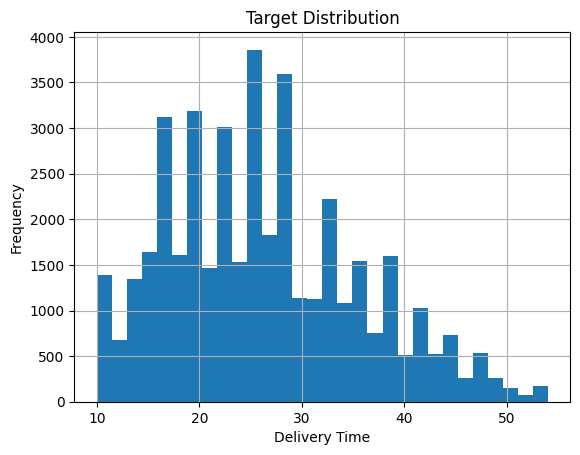

In [182]:
df["Time_taken(min)"].hist(bins=30)
plt.xlabel("Delivery Time")
plt.ylabel("Frequency")
plt.title("Target Distribution")
plt.show()

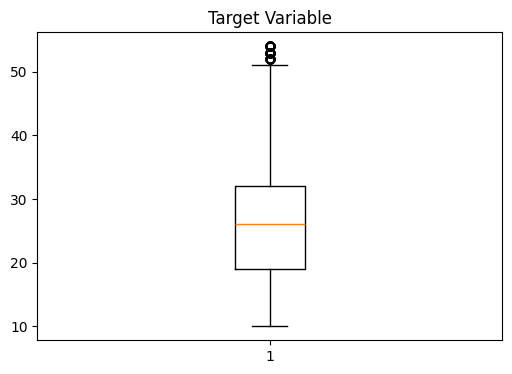

In [183]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Time_taken(min)"])
plt.title("Target Variable")
plt.show()

In [184]:
numeric_columns = df.select_dtypes(include="number").columns
df[numeric_columns].describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min)
count,40234.000000,40190.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41048.000000,41953.000000
mean,29.563330,4.632386,18.911397,76.923408,18.975064,76.987074,1.022716,0.745249,26.311539
std,5.812361,0.335541,5.467829,3.502910,5.469616,3.503073,0.838893,0.572152,9.380753
min,15.000000,1.000000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.986047,73.898520,13.065996,73.940327,0.000000,0.000000,19.000000
50%,30.000000,4.700000,19.065838,76.618203,19.123249,76.663622,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [185]:
for col in categorical_columns:
    print(". . . . "*10)
    print(col)
    print(df[col].value_counts())

. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
Weatherconditions
conditions Fog           7012
conditions Stormy        6974
conditions Cloudy        6932
conditions Sandstorms    6906
conditions Windy         6832
conditions Sunny         6728
conditions NaN            569
Name: Weatherconditions, dtype: int64
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
Road_traffic_density
Low        14200
Jam        13043
Medium     10084
High        4071
NaN          555
Name: Road_traffic_density, dtype: int64
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
Type_of_order
Snack      10616
Meal       10524
Drinks     10445
Buffet     10368
Name: Type_of_order, dtype: int64
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 
Type_of_vehicle
motorcycle           24396
scooter              14029
electric_scooter      3468
bicycle                 60
Name: Type_of_vehicle, 

In [186]:
date_columns = [
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked"
]
df[date_columns].head()

,Order_Date,Time_Orderd,Time_Order_picked
0,19-03-2022,11:33:33,11:45:29
1,25-03-2022,19:45:37,19:51:49
2,19-03-2022,8:32:58,8:48:47
3,05-04-2022,18:03:58,18:12:52
4,26-03-2022,13:34:16,13:45:36


In [203]:
numeric_missing_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries"
]

df[numeric_missing_cols].sample(5)

,Delivery_person_Age,Delivery_person_Ratings,multiple_deliveries
30280,29.0,4.8,1.0
39858,36.0,4.8,0.0
10241,39.0,3.5,2.0
26878,21.0,4.9,1.0
29497,25.0,4.8,1.0


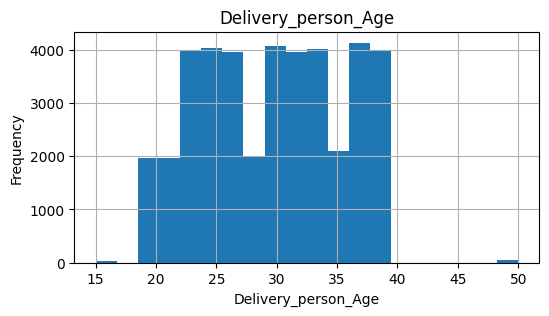

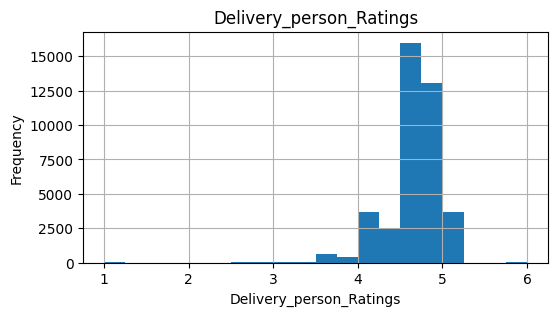

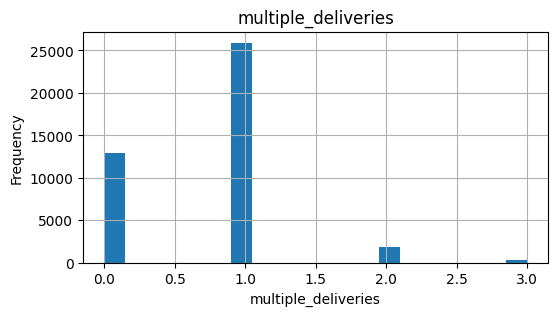

In [195]:
for col in numeric_missing_cols:
    plt.figure(figsize=(6, 3))
    df[col].hist(bins=20)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [204]:
age_median = df["Delivery_person_Age"].median()
df["Delivery_person_Age"].fillna(age_median,inplace=True)

In [206]:
rating_median=df["Delivery_person_Ratings"].median()
df["Delivery_person_Ratings"].fillna(rating_median,inplace=True)

In [207]:
delivery_mode = df["multiple_deliveries"].mode()[0]
df["multiple_deliveries"].fillna(delivery_mode, inplace=True)

In [209]:
delivery_mode=df["multiple_deliveries"].mode()[0]
df["multiple_deliveries"].fillna(delivery_mode,inplace=True)

In [213]:
df[["Delivery_person_Age","Delivery_person_Ratings","multiple_deliveries"]].isnull().sum()

Delivery_person_Age        0
Delivery_person_Ratings    0
multiple_deliveries        0
dtype: int64

In [214]:
df["Weatherconditions"].unique()

array(['conditions Sunny', 'conditions Stormy', 'conditions Sandstorms',
       'conditions Cloudy', 'conditions Fog', 'conditions Windy',
       'conditions NaN'], dtype=object)

In [218]:
df["Weatherconditions"] = (
    df["Weatherconditions"]
      .str.replace("conditions ", "", regex=False)
)
df["Weatherconditions"].unique()

array(['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', 'NaN'],
      dtype=object)

In [219]:
df["Delivery_person_Age"].dtype

dtype('float64')

In [223]:
df["Delivery_person_Age"].unique()[:25]

array([37., 34., 23., 38., 32., 22., 33., 35., 36., 21., 24., 29., 25.,
       31., 27., 26., 20., 30., 28., 39., 15., 50.])

In [226]:
df["multiple_deliveries"].unique()

array([0., 1., 3., 2.])

In [227]:
print(df["Delivery_person_Age"].dtype)
print(df["Delivery_person_Ratings"].dtype)
print(df["multiple_deliveries"].dtype)

float64
float64
float64


In [228]:
df[
    [
        "Delivery_person_Age",
        "Delivery_person_Ratings",
        "multiple_deliveries",
        "Weatherconditions"
    ]
].head()

,Delivery_person_Age,Delivery_person_Ratings,multiple_deliveries,Weatherconditions
0,37.0,4.9,0.0,Sunny
1,34.0,4.5,1.0,Stormy
2,23.0,4.4,1.0,Sandstorms
3,38.0,4.7,1.0,Sunny
4,32.0,4.6,1.0,Cloudy
